In [1]:
import pandas as pd
from prophet import Prophet
import tqdm as notebook_tqdm
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
file_path = "AprilSales-2024.csv"

df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d/%m/%Y"
)

df = df.sort_values("Date")

df.head()

,Date,Total_Daily_Sales,Total_Units_Sold
0,2024-04-01,73089.0,422.0
1,2024-04-02,78184.0,421.0
2,2024-04-03,79333.0,409.0
3,2024-04-04,66020.0,367.0
4,2024-04-05,75599.0,475.0


In [3]:
prophet_df = df.rename(
    columns={
        "Date": "ds",
        "Total_Daily_Sales": "y"
    }
)

prophet_df = prophet_df[
    ["ds", "y"]
]

In [4]:
model = Prophet(

    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,

    seasonality_mode="multiplicative"
)

model.fit(prophet_df)

13:54:06 - cmdstanpy - INFO - Chain [1] start processing
13:54:07 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
future = model.make_future_dataframe(

    periods=365,
    freq="D"
)

forecast = model.predict(future)

In [6]:
last_actual_date = prophet_df["ds"].max()

future_predictions = forecast[
    forecast["ds"] > last_actual_date
]

In [7]:
end_of_april = datetime(
    last_actual_date.year,
    last_actual_date.month,
    30
)

april_predictions = forecast[
    (forecast["ds"] > last_actual_date)
    &
    (forecast["ds"] <= end_of_april)
]

In [8]:
april_predictions[
    ["ds", "yhat"]
].to_csv(

    "April_2024_Predictions.csv",
    index=False
)

In [9]:
future_predictions[
    ["ds", "yhat"]
].to_csv(

    "Year_2024_Predictions.csv",
    index=False
)

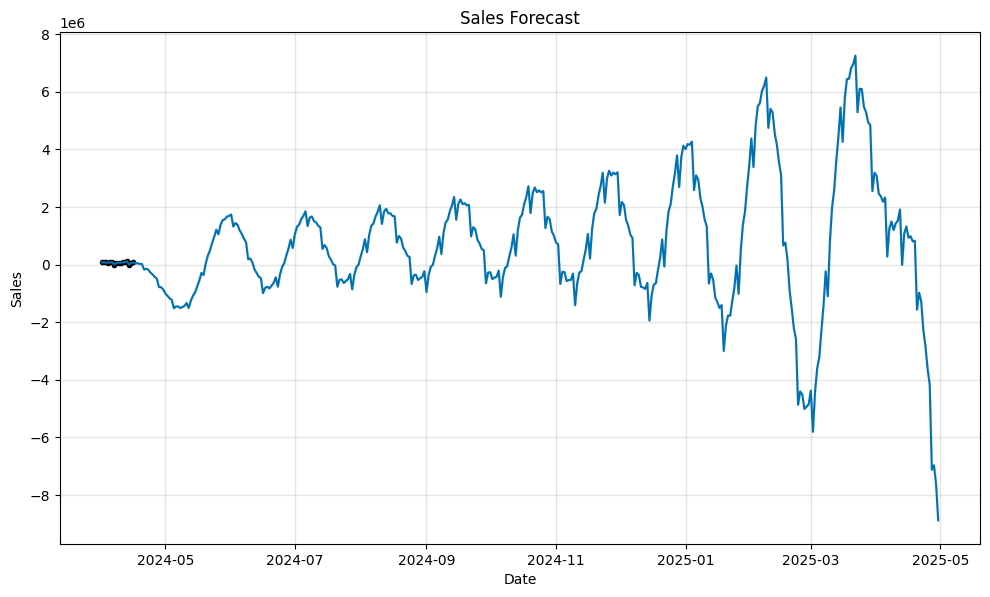

In [10]:
model.plot(forecast)

plt.title("Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

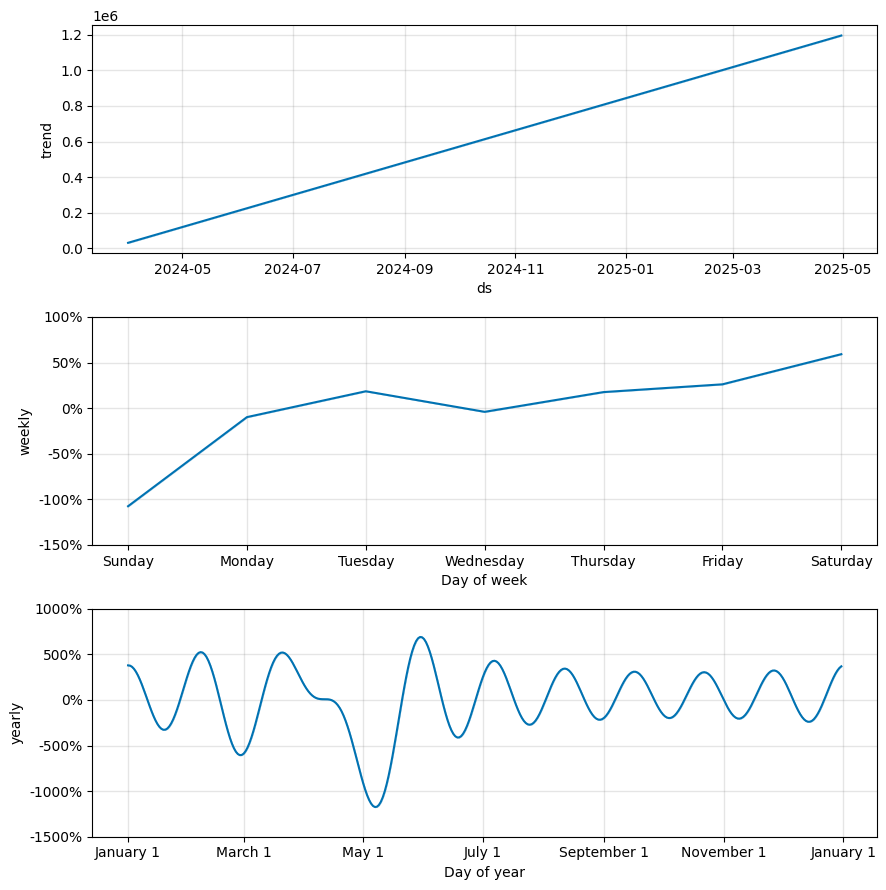

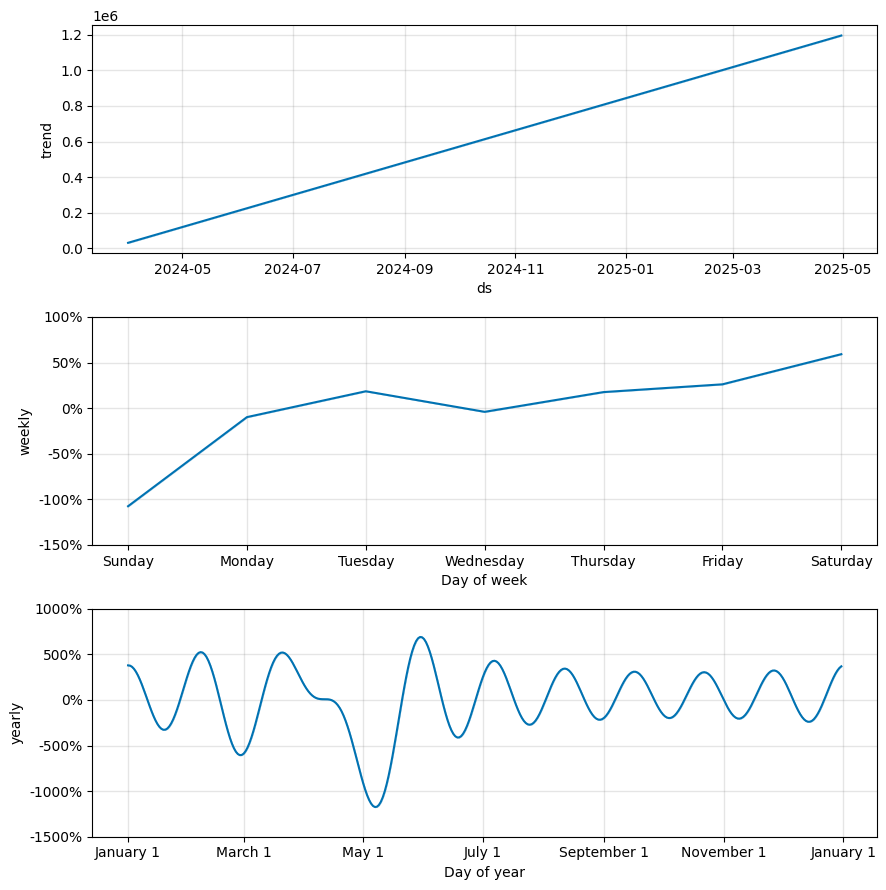

In [11]:
model.plot_components(forecast)